In [1]:
import pandas as pd
df = pd.read_csv("netflix1.csv")
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [2]:
df.shape

(8790, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 377.8+ KB


In [4]:
df.columns = df.columns.str.replace("_", " ").str.title()

In [5]:
df.columns

Index(['Show Id', 'Type', 'Title', 'Director', 'Country', 'Date Added',
       'Release Year', 'Rating', 'Duration', 'Listed In'],
      dtype='object')

In [8]:
df["Type"].value_counts()

Type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [10]:
df["Release Year"].value_counts().sort_index()

Release Year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [13]:
df["Release Year"].value_counts().sort_index().head(20)

Release Year
1925    1
1942    2
1943    3
1944    3
1945    4
1946    2
1947    1
1954    2
1955    3
1956    2
1958    3
1959    1
1960    4
1961    1
1962    3
1963    2
1964    2
1965    2
1966    1
1967    5
Name: count, dtype: int64

In [14]:
df["Release Year"].value_counts().sort_index().tail(20)

Release Year
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     286
2014     352
2015     555
2016     901
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

In [18]:
df["Country"].str.split(", ").explode().value_counts().head(10)

Country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

In [19]:
df["Listed In"].str.split(", ").explode().value_counts().head(10)

Listed In
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [20]:
df["Rating"].value_counts()

Rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [21]:
type_counts = df["Type"].value_counts()
type_counts

Type
Movie      6126
TV Show    2664
Name: count, dtype: int64

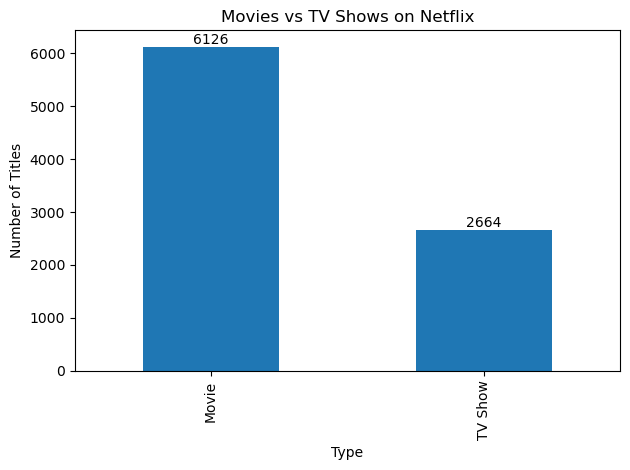

In [63]:
import matplotlib.pyplot as plt

type_counts = df["Type"].value_counts()

ax = type_counts.plot(kind="bar")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

# Add numbers on top of each bar
for i, v in enumerate(type_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("movies_vs_tv.png", bbox_inches="tight")
plt.show()

In [24]:
year_counts = df["Release Year"].value_counts().sort_index()
year_counts.head()

Release Year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

In [29]:
year_counts = df["Release Year"].value_counts().sort_index()
year_counts

Release Year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [31]:
year_counts = df["Release Year"].value_counts().sort_index()
recent = year_counts[year_counts.index >= 2000]

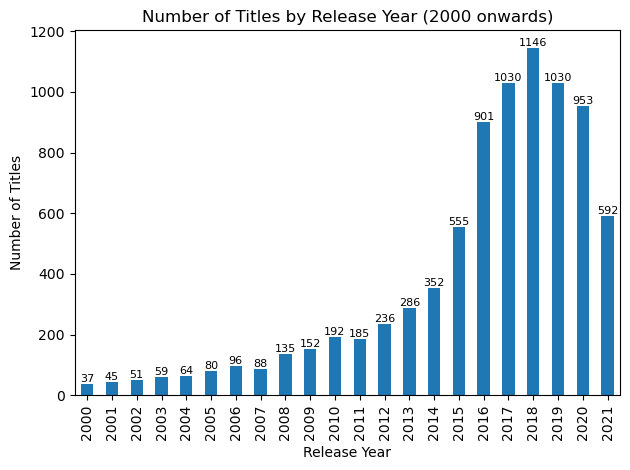

In [64]:
import matplotlib.pyplot as plt

ax = recent.plot(kind="bar")
plt.title("Number of Titles by Release Year (2000 onwards)")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

# Add numbers on top of each bar
for i, v in enumerate(recent.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("release_year_bar.png", bbox_inches="tight")
plt.show()

In [34]:
top_countries = df["Country"].str.split(", ").explode().value_counts().head(10)
top_countries

Country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

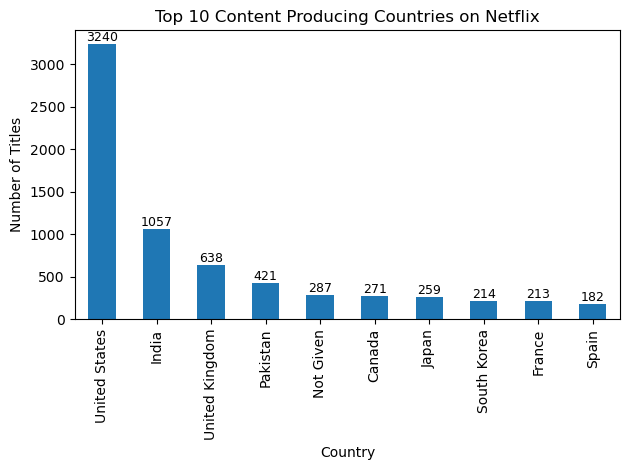

In [65]:
import matplotlib.pyplot as plt

ax = top_countries.plot(kind="bar")
plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

# Add numbers on top of bars
for i, v in enumerate(top_countries.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("top_countries.png", bbox_inches="tight")
plt.show()

In [36]:
rating_counts = df["Rating"].value_counts()
rating_counts

Rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

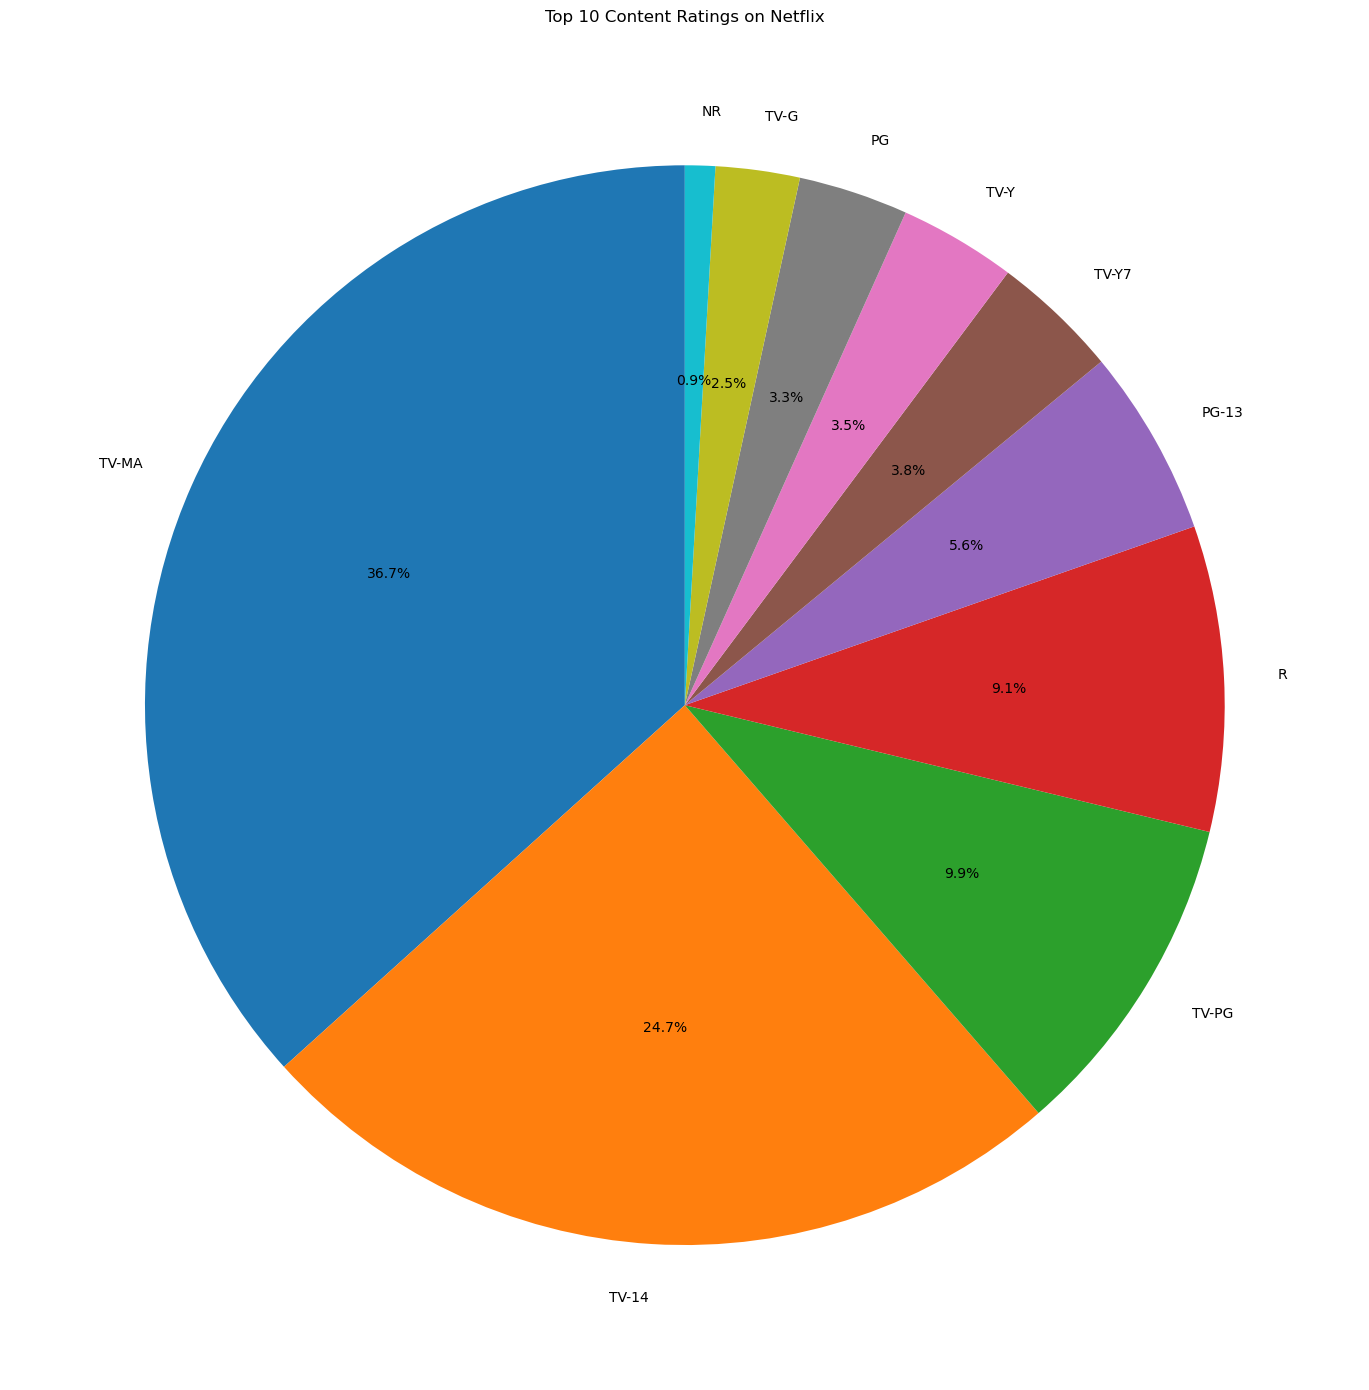

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
plt.pie(rating_counts.head(10).values, labels=rating_counts.head(10).index, autopct="%1.1f%%", startangle=90)
plt.title("Top 10 Content Ratings on Netflix")
plt.tight_layout()
plt.savefig("ratings_top10_pie.png", bbox_inches="tight")
plt.show()

In [67]:
genres_counts = df["Listed In"].str.split(", ").explode().value_counts().head(10)
genres_counts

Listed In
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

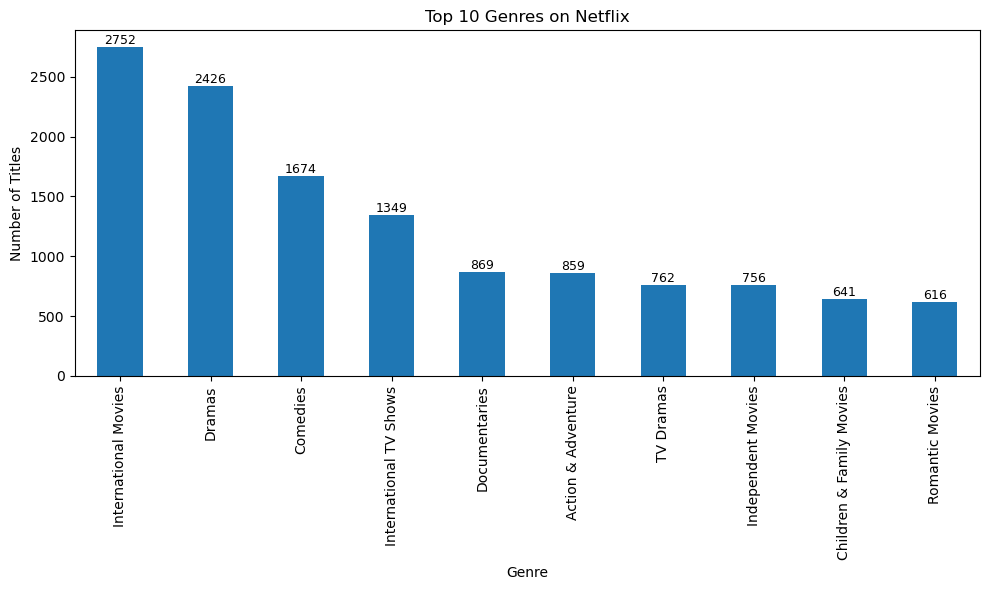

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = genres_counts.plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

# Add numbers on top
for i, v in enumerate(genres_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("top_genres.png", bbox_inches="tight")
plt.show()

In [52]:
# Count titles by Release Year and Type
year_type_counts = df.groupby(["Release Year", "Type"]).size().unstack().fillna(0)

# Keep only recent years for clarity (e.g., 2000+)
year_type_counts = year_type_counts[year_type_counts.index >= 2000]

year_type_counts.head()

Type,Movie,TV Show
Release Year,,
2000,33.0,4.0
2001,40.0,5.0
2002,44.0,7.0
2003,51.0,8.0
2004,55.0,9.0


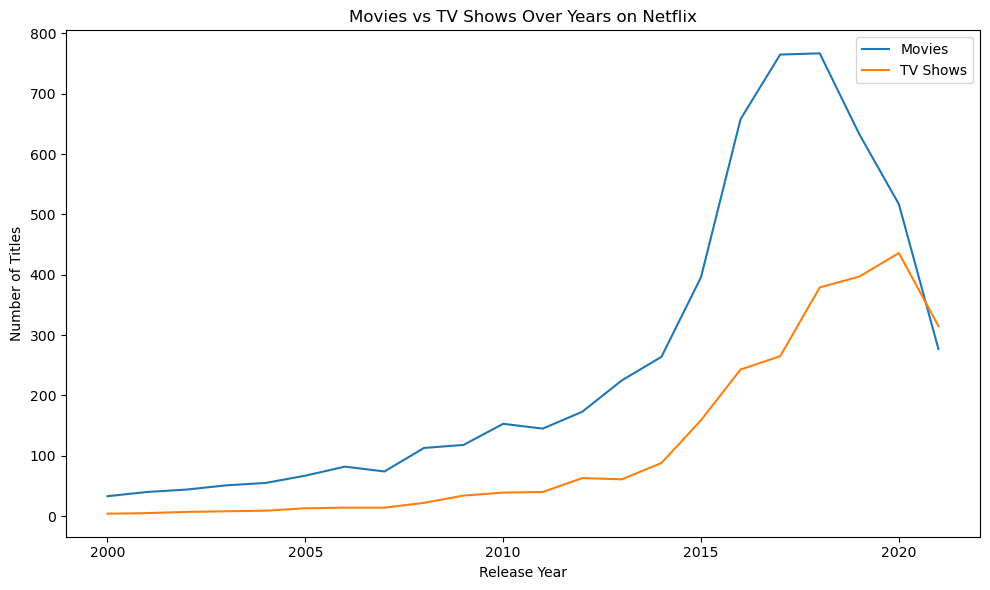

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(year_type_counts.index, year_type_counts["Movie"], label="Movies")
plt.plot(year_type_counts.index, year_type_counts["TV Show"], label="TV Shows")

plt.title("Movies vs TV Shows Over Years on Netflix")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.tight_layout()
plt.savefig("movies_vs_tv_over_years.png", bbox_inches="tight")
plt.show()